# Laboratory work 3

## Modeling a Bayesian classifier for Gaussian random vectors

Imporing libs


In [327]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Making class to work with Bayesian classifier

In [328]:
from collections.abc import Callable

class Bayesian_Classifier:
    def __init__(self, N: int, L:int):
        self.N = N
        self.L = L
        self.a_priori_probabilities = []
        self.conditional_densities = []

    def _gaussian_density_one_point(self, mu: np.ndarray, sigma: np.ndarray)->Callable:
        density = lambda x: (2 * np.pi) ** (-self.N/2) * np.linalg.det(sigma) ** (-1/2) \
            * np.exp(-(x - mu).T @ np.linalg.inv(sigma) @ (x - mu) / 2)
        return density

    def gaussian_density(self, mu: np.ndarray, sigma:np.ndarray)->list[Callable]:
        densities = []
        for i in range(self.L):
            densities.append(self._gaussian_density_one_point(mu[i], sigma[i]))
        
        return densities
    
    def set_probability_characteristics(self, apriory_probabilities: list[float],
                                         conditional_densities: list[Callable])->None:
        self.a_priori_probabilities = apriory_probabilities
        self.conditional_densities = conditional_densities

    def predict(self, x: np.ndarray)->list[float]:
        a_posteriori_probabilities: list[float] = []
        f: list[float] = []
        for i in range(self.L):
            f.append(self.a_priori_probabilities[i] * self.conditional_densities[i](x))

        summ = sum(f)
        for i in range(self.L):
            a_posteriori_probabilities.append(f[i] / summ)

        return a_posteriori_probabilities
    
    def fit(self, X: np.ndarray, y: np.ndarray)->None:
        self.a_priori_probabilities = []
        self.densities = []
        for i in range(self.L):
            mask = (y == (i+1))
            count = len(y[mask])
            self.a_priori_probabilities.append(count / len(y))

            mean = np.mean(X[mask], axis=0)
            cov = np.cov(X[mask], rowvar=False)
            density = self._gaussian_density_one_point(mean, cov)
            self.densities.append(density)
        return None

Declarating function to draw ellipsoid of conditional gaussian densities

In [329]:
from scipy.stats import chi2
from matplotlib.patches import Ellipse

def plot_ellipsoid(ax, mu: np.ndarray, sigma: np.ndarray, color: str, alpha=0.95):
    chi2_val = chi2.ppf(alpha, df=2)
    eigvals, eigvecs = np.linalg.eigh(sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width = 2 * np.sqrt(eigvals[0] * chi2_val)
    height = 2 * np.sqrt(eigvals[1] * chi2_val)
    
    ell = Ellipse(xy=mu.tolist(), width=width, height=height, angle=angle, color=color)
    ax.add_patch(ell)

### 1. All probability characteristics are known.

$N=2, L=2, \pi_1 = \pi_2 = 0.5, M_i=M_i'=20, i=1,2, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(1, 1)^T$

In [330]:
bc = Bayesian_Classifier(2, 2)
a_priori = [0.5, 0.5]
mu_1 = np.array([-1, -1])
mu_2 = np.array([1, 1])
mus = np.stack((mu_1, mu_2))

A) $\Sigma_1=\Sigma_2=\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$

In [331]:
sigma = np.array([[1, 0], [0, 1]])
sigmas_a = np.stack((sigma, sigma))

In [332]:
densities = bc.gaussian_density(mus, sigmas_a)

bc.set_probability_characteristics(a_priori, densities)
x1 = np.array([-2, -2])
x2 = np.array([2, 2])
x3 = np.array([0, 0])
print(bc.predict(x1))
print(bc.predict(x2))
print(bc.predict(x3))

[np.float64(0.9996646498695335), np.float64(0.0003353501304664781)]
[np.float64(0.0003353501304664781), np.float64(0.9996646498695335)]
[np.float64(0.5), np.float64(0.5)]


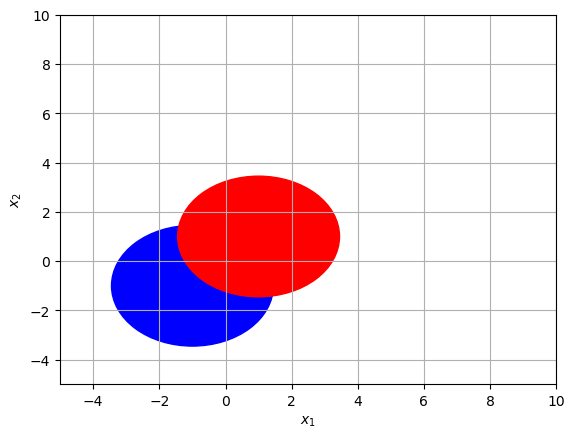

In [333]:
fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma, 'blue')
plot_ellipsoid(ax, mu_2, sigma, 'red')
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

In [334]:
n_samples = 10

random_variables1 = np.random.multivariate_normal(mu_1, sigma, n_samples)
random_variables2 = np.random.multivariate_normal(mu_2, sigma, n_samples)
df1 = pd.DataFrame(random_variables1, columns=['x', 'y'])
df1['label'] = 1
df2 = pd.DataFrame(random_variables2, columns=['x', 'y'])
df2['label'] = 2

df_test = pd.concat([df1, df2], ignore_index=True)
df_test = df_test.sample(frac=1).reset_index(drop=True)
df_test.head()

,x,y,label
0,-1.819278,-2.954313,1
1,0.984479,0.821577,2
2,-2.505350,-1.245537,1
3,0.211042,1.945148,2
4,1.218270,2.679542,2


In [350]:
bc.fit(df_test[['x', 'y']].to_numpy(), df_test['label'].to_numpy())
bc.predict(x3)

[np.float64(0.8528313070257071), np.float64(0.147168692974293)]

B) $\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$, $\Sigma_2 = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix}$

In [336]:
sigma_b1 = np.array([[1, 0], [0, 1]])
sigma_b2 = np.array([[2, 0], [0, 2]])
sigmas_b = np.stack((sigma_b1, sigma_b2))
densities = bc.gaussian_density(mus, sigmas_b)

In [337]:
bc.set_probability_characteristics(a_priori, densities)
x1 = np.array([-2, -2])
x2 = np.array([2, 2])
x3 = np.array([0, 0])
print(bc.predict(x1))
print(bc.predict(x2))
print(bc.predict(x3))

[np.float64(0.98512588792159), np.float64(0.014874112078410105)]
[np.float64(0.00040677120787283564), np.float64(0.9995932287921271)]
[np.float64(0.548137238122394), np.float64(0.45186276187760605)]


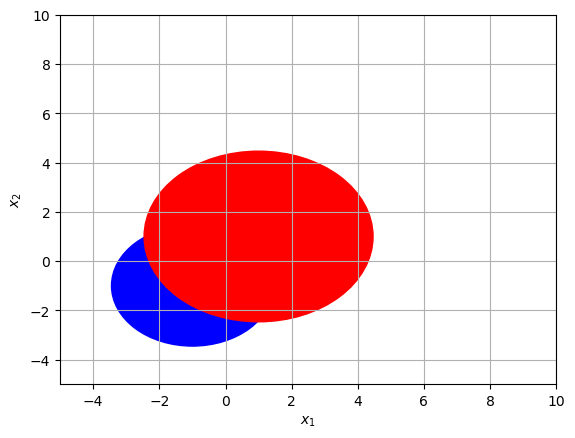

In [338]:
fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_b1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_b2, 'red')
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

C) $\Sigma_1 = \begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix}$, $\Sigma_2 = \begin{pmatrix} 2 & -1.5 \\ -1.5 & 2 \end{pmatrix}$

In [339]:
sigma_c1 = np.array([[1, 0.5], [0.5, 1]])
sigma_c2 = np.array([[2, -1.5], [-1.5, 2]])
sigmas_c = np.stack((sigma_c1, sigma_c2))
densities = bc.gaussian_density(mus, sigmas_c)

In [340]:
bc.set_probability_characteristics(a_priori, densities)
x1 = np.array([-2, -2])
x2 = np.array([2, 2])
x3 = np.array([0, 0])
print(bc.predict(x1))
print(bc.predict(x2))
print(bc.predict(x3))

[np.float64(0.9999999805803866), np.float64(1.9419613373723056e-08)]
[np.float64(0.027216157746792563), np.float64(0.9727838422532075)]
[np.float64(0.8528313070257071), np.float64(0.147168692974293)]


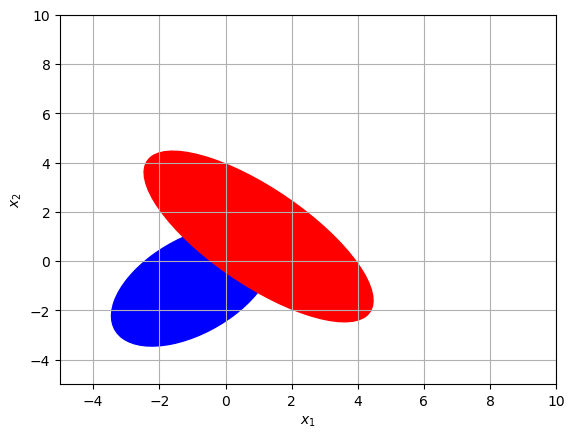

In [341]:
fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma_c1, 'blue')
plot_ellipsoid(ax, mu_2, sigma_c2, 'red')
plt.xlim(-5, 10)
plt.xlabel(r"$x_1$")
plt.ylim(-5, 10)
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

$N=2, L=4, \pi_1 = \pi_i = 0.25, M_i=M_i'=20, i=\overline{1,4}, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(-1, 1)^T,\ \mu_3=(1, 1)^T,\ \mu_4=(1,-1)^T$

$\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix},\ \Sigma_2 = \begin{pmatrix} 1 & 0.5 \\ 0.5 & 1 \end{pmatrix},\ \Sigma_3 = \begin{pmatrix} 2 & 0 \\ 0 & 2 \end{pmatrix},\ \Sigma_4 = \begin{pmatrix} 1 & -0.5 \\ -0.5 & 1 \end{pmatrix}$

In [342]:
bc2 = Bayesian_Classifier(N=2, L=4)
a_priori = [0.25, 0.25, 0.25, 0.25]

mu_1 = np.array([-1, -1])
mu_2 = np.array([-1, 1])
mu_3 = np.array([1, 1])
mu_4 = np.array([1, -1])
mus = np.stack((mu_1, mu_2, mu_3, mu_4))

sigma_1 = np.array([[1, 0], [0, 1]])
sigma_2 = np.array([[1, 0.5], [0.5, 1]])
sigma_3 = np.array([[2, 0], [0, 2]])
sigma_4 = np.array([[1, -0.5], [-0.5, 1]])
sigmas = np.stack((sigma_1, sigma_2, sigma_3, sigma_4))

In [343]:
densities = bc2.gaussian_density(mus, sigmas)
bc2.set_probability_characteristics(a_priori, densities)

x1 = np.array([0, 0])
x2 = np.array([1, 1])
print(bc2.predict(x1))
print(bc2.predict(x2))

[np.float64(0.25902269000662936), np.float64(0.11003040099512004), np.float64(0.21352810930394764), np.float64(0.41741879969430284)]
[np.float64(0.026983142419110415), np.float64(0.11820101424937246), np.float64(0.7366148290821446), np.float64(0.11820101424937246)]
